# SpinDefectSim — Quick Start

A hands-on tour covering:

1. Single-defect spin physics and ODMR transitions
2. CW ODMR spectra (single defect + inhomogeneous ensemble)
3. Hahn-echo and Ramsey lock-in signals
4. AC sensing pulse sequences and shot-noise SNR
5. Electric-field sources (gate bias, screened Coulomb disorder)
6. Electrometry scan maps (`ElectrometryExperiment`)
7. Full ensemble E-field sensing workflow
8. Magnetic-field sources (Biot–Savart from magnetization)
9. Magnetometry scan maps (`MagnetometryExperiment`)
10. Ensemble B-field sensing and combined E + B sensing
11. Parameter sweeps
12. Nuclear spins and hyperfine interaction
13. CW ODMR contrast — rate model

> Physical models and formulae: see **`theory.md`** (§10 nuclear spins, §11 rate model).


In [1]:
import sys
sys.path.insert(0, "/app")

import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import e as e_charge

from SpinDefectSim.base.params import Defaults
from SpinDefectSim.spin.hamiltonian import SpinDefect, SpinParams, odmr_hamiltonian_Hz
from SpinDefectSim.spin.spectra import (
    ensemble_odmr_spectrum, ensemble_transitions_from_Efields, lorentzian,
)
from SpinDefectSim.spin.echo import lock_in_difference_echo, lock_in_difference_ramsey
from SpinDefectSim.sensing.protocols import SensingExperiment
from SpinDefectSim.sensing.sequences import RamseySequence, HahnEchoSequence, XY8Sequence
from SpinDefectSim.sensing.snr import snr, n_avg_for_threshold
from SpinDefectSim.electrometry.efield import E_disorder_point_charges, E_gate_bias
from SpinDefectSim.electrometry import ElectrometryExperiment
from SpinDefectSim.magnetometry import SquareGeometry, MagnetometryExperiment
from SpinDefectSim.magnetometry.bfield import B_from_magnetization_grid
from SpinDefectSim.analysis.ensemble import DefectEnsemble

d = Defaults()
print(d)

Defaults(defect_type='vb_minus', D0_Hz=3460000000.0, E0_Hz=50000000.0, d_perp=0.35, d_parallel=0.0, B_mT=1.5, gamma_e=28000000000.0, T2star=5e-08, T2echo=1e-05, contrast=None, n_photons=500, k_optical=None, N_def=1200, R_laser=5e-07, R_patch=2e-07, z_defect=3.4e-10, epsilon_eff=7.0, eps_layer=None, eps_host=None, screening_model='dual_gate', lambda_screen=1e-08, d_gate=1.5e-08, n_images=30, r_min=2e-10)


## 1. Single VB⁻ defect

The spin-1 Hamiltonian (see `theory.md §1`) is:

$$\frac{H}{h} = D_0\left(S_z^2 - \tfrac{2}{3}I\right) + E_0(S_x^2-S_y^2) + d_\perp\left[E_y(S_x^2-S_y^2) + E_x\{S_x,S_y\}\right] + \gamma_e\,\vec{B}\cdot\vec{S}$$

`SpinDefect` diagonalises this on demand and exposes the two ODMR transition frequencies.


SpinDefect(type='vb_minus', S=1, D0=3.460 GHz, E0=50.0 MHz, |B|=1.50 mT, 3 nuclear spin(s))


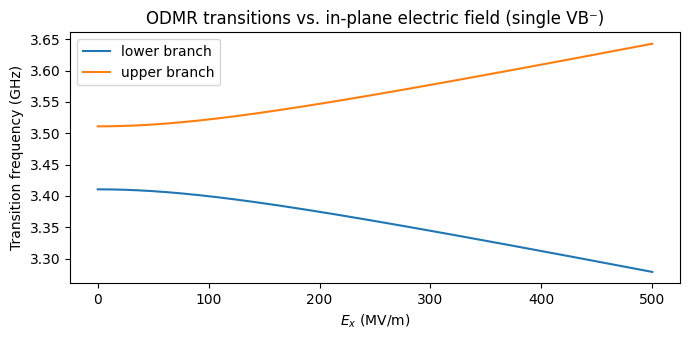

In [2]:
defect = SpinDefect(B_mT=1.5, defaults=d)
print(defect)

# Sweep transverse E-field and track transition frequencies
E_x = np.linspace(0, 5000e5, 300)
freqs = np.array([defect.transition_frequencies([Ex, 0, 0]) for Ex in E_x])

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(E_x / 1e6, freqs[:, 0] / 1e9, label="lower branch")
ax.plot(E_x / 1e6, freqs[:, 1] / 1e9, label="upper branch")
ax.set_xlabel("$E_x$ (MV/m)")
ax.set_ylabel("Transition frequency (GHz)")
ax.set_title("ODMR transitions vs. in-plane electric field (single VB⁻)")
ax.legend()
plt.tight_layout()
plt.show()

## 2. CW ODMR spectrum

Each transition is modelled with a Lorentzian of FWHM $\Delta f = (\pi T_2^*)^{-1}$:
$$\text{PL}(f) = 1 - C\sum_i \mathcal{L}(f; f_i, \Delta f)$$
(see `theory.md §3`).

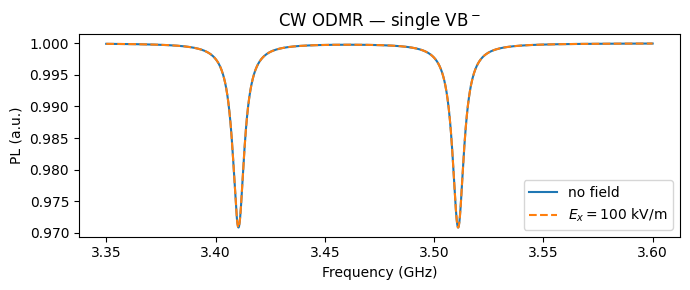

In [3]:
sp = d.to_spin_params()
f_axis = np.linspace(3.35e9, 3.60e9, 2000)
fwhm = 1.0 / (np.pi * d.T2star)
C = d.get_contrast()

f1, f2 = defect.transition_frequencies([0, 0, 0])
pl_bare = 1 - C * (lorentzian(f_axis, f1, fwhm) + lorentzian(f_axis, f2, fwhm))

f1s, f2s = defect.transition_frequencies([1e5, 0, 0])
pl_shift = 1 - C * (lorentzian(f_axis, f1s, fwhm) + lorentzian(f_axis, f2s, fwhm))

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(f_axis / 1e9, pl_bare, label="no field")
ax.plot(f_axis / 1e9, pl_shift, ls="--", label=r"$E_x = 100$ kV/m")
ax.set_xlabel("Frequency (GHz)"); ax.set_ylabel("PL (a.u.)")
ax.set_title("CW ODMR — single VB$^-$"); ax.legend()
plt.tight_layout(); plt.show()


## 3. Inhomogeneous ensemble — CW ODMR

In a real experiment you integrate over many defects each with a different local
E-field, which inhomogeneously broadens the lines.  The ensemble PL is averaged
incoherently: $\overline{\text{PL}}(f) = N^{-1}\sum_n \text{PL}^{(n)}(f)$.

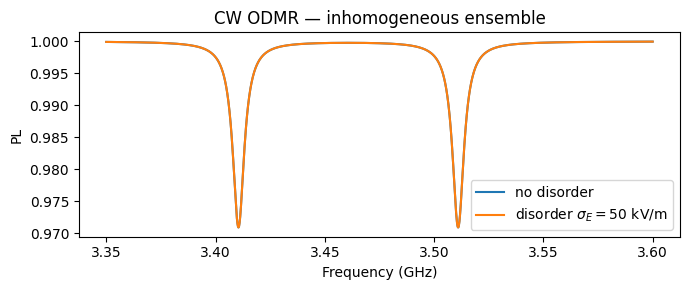

In [4]:
rng = np.random.default_rng(42)
N, E_rms = 500, 5e4   # 500 defects, 50 kV/m rms
E_fields = rng.normal(0, E_rms, (N, 3)); E_fields[:, 2] = 0
transitions = ensemble_transitions_from_Efields(E_fields, sp)

E_zero = np.zeros((N, 3))
tr_zero = ensemble_transitions_from_Efields(E_zero, sp)

C = d.get_contrast()
fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(f_axis / 1e9, ensemble_odmr_spectrum(f_axis, tr_zero, fwhm, C), label="no disorder")
ax.plot(f_axis / 1e9, ensemble_odmr_spectrum(f_axis, transitions, fwhm, C),
        label=f"disorder $\sigma_E={E_rms/1e3:.0f}$ kV/m")
ax.set_xlabel("Frequency (GHz)"); ax.set_ylabel("PL"); ax.legend()
ax.set_title("CW ODMR — inhomogeneous ensemble")
plt.tight_layout(); plt.show()


## 4. Hahn-echo lock-in signal

The Hahn-echo refocusing $\pi$-pulse cancels quasi-static noise.  The lock-in differential
$\Delta S(\tau) = S_\text{with} - S_\text{no}$ peaks near $\tau_\text{opt} \approx T_2$
(see `theory.md §4.2`):

$$S_\text{echo}(\tau) = \langle\cos(2\pi\,\delta f\,\tau)\rangle_\text{ens}\;e^{-\tau/T_2}$$


Peak |ΔS| = 0.1662  at τ = 12.17 µs


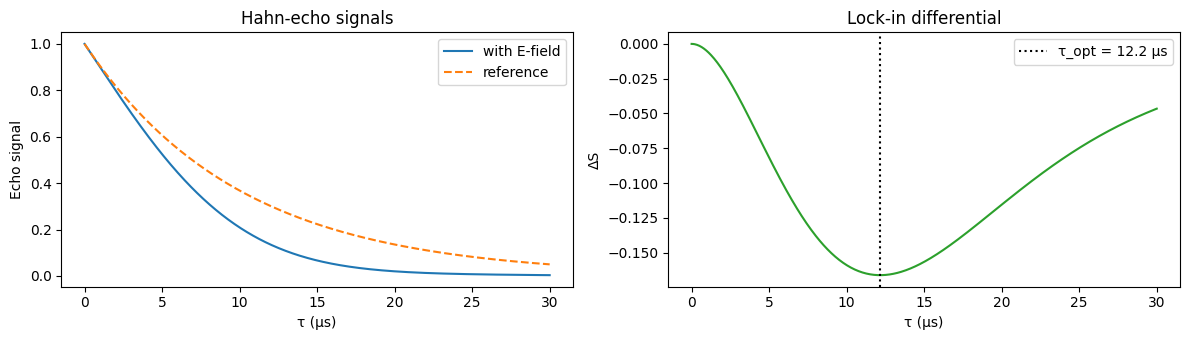

In [5]:
tau_s = np.linspace(0, 3.0 * d.T2echo, 600)
Sw, Sn, dS = lock_in_difference_echo(transitions, tr_zero, tau_s, d.T2echo)
idx = np.argmax(np.abs(dS))
print(f"Peak |ΔS| = {abs(dS[idx]):.4f}  at τ = {tau_s[idx]*1e6:.2f} µs")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(tau_s*1e6, Sw, label="with E-field")
axes[0].plot(tau_s*1e6, Sn, ls="--", label="reference")
axes[0].set_xlabel("τ (µs)"); axes[0].set_ylabel("Echo signal")
axes[0].set_title("Hahn-echo signals"); axes[0].legend()

axes[1].plot(tau_s*1e6, dS, color="C2")
axes[1].axvline(tau_s[idx]*1e6, color="k", ls=":", label=f"τ_opt = {tau_s[idx]*1e6:.1f} µs")
axes[1].set_xlabel("τ (µs)"); axes[1].set_ylabel("ΔS")
axes[1].set_title("Lock-in differential"); axes[1].legend()
plt.tight_layout(); plt.show()

## 5. Ramsey free-induction decay

Sensitive to quasi-static frequency shifts; decays at rate $1/T_2^*$:
$$S_\text{Ramsey}(\tau) = \langle 1 - C\cos(2\pi\,\delta f\,\tau)\rangle_\text{ens}\;e^{-\tau/T_2^*}$$


Ramsey peak |ΔS| = 0.0000  at τ = 100.1 ns


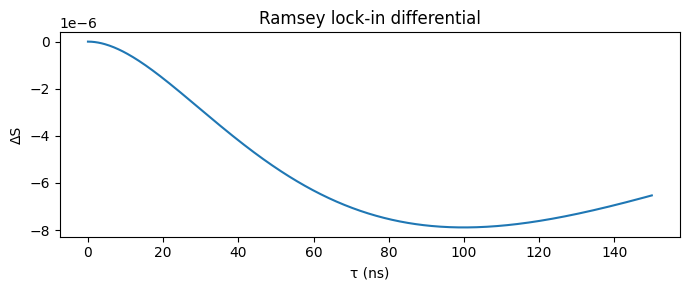

In [6]:
tau_r = np.linspace(0, 3.0 * d.T2star, 500)
Sw_r, Sn_r, dS_r, _ = lock_in_difference_ramsey(transitions, tr_zero, tau_r, d.T2star)
idx_r = np.argmax(np.abs(dS_r))
print(f"Ramsey peak |ΔS| = {abs(dS_r[idx_r]):.4f}  at τ = {tau_r[idx_r]*1e9:.1f} ns")

fig, ax = plt.subplots(figsize=(7, 3))
ax.plot(tau_r*1e9, dS_r); ax.set_xlabel("τ (ns)")
ax.set_ylabel("ΔS"); ax.set_title("Ramsey lock-in differential")
plt.tight_layout(); plt.show()

## 6. AC sensing — pulse sequences and SNR

For an AC target field at $f_\text{AC} = 1/(2\tau)$, multi-pulse sequences
accumulate sensitivity. `repetition_rate(τ)` gives shots per second.

SNR after $N_\text{avg}$ averages: $\text{SNR} = |\Delta S|\,C\sqrt{N_\text{ph}\,N_\text{avg}}$
(see `theory.md §5`).

In [7]:
seq_ramsey = RamseySequence()
seq_echo   = HahnEchoSequence()
seq_xy8    = XY8Sequence()

tau_ac = 5e-6  # sensing τ for a 100 kHz AC field

print(f"{'Sequence':12s}  shot time   rep rate    N in 60 s")
for name, seq in [("Ramsey", seq_ramsey), ("Hahn-echo", seq_echo), ("XY8", seq_xy8)]:
    t_shot = seq.total_time(tau_ac)
    r_rep  = seq.repetition_rate(tau_ac)
    n_60   = seq.n_avg_in_time(60.0, tau_ac)
    print(f"{name:12s}  {t_shot*1e6:.1f} µs      {r_rep/1e3:.1f} kHz     {n_60:.2e}")

Sequence      shot time   rep rate    N in 60 s
Ramsey        6.3 µs      158.2 kHz     9.49e+06
Hahn-echo     11.3 µs      88.2 kHz     5.29e+06
XY8           81.5 µs      12.3 kHz     7.36e+05


Need 23603 averages for SNR=5
  Hahn-echo integration time: 0.3 s
  XY8 integration time:       1.9 s


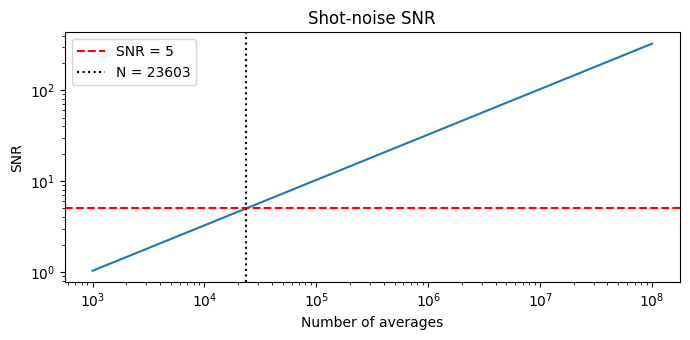

In [8]:
# SNR vs. number of averages
dS_signal = 0.05
N_arr = np.logspace(3, 8, 300)
C = d.get_contrast()
snr_vals = snr(dS_signal, N_arr, C, d.n_photons)

N_thresh = n_avg_for_threshold(dS_signal, snr_target=5.0, contrast=C, n_photons=d.n_photons)
print(f"Need {N_thresh:.0f} averages for SNR=5")
print(f"  Hahn-echo integration time: {N_thresh / seq_echo.repetition_rate(tau_ac):.1f} s")
print(f"  XY8 integration time:       {N_thresh / seq_xy8.repetition_rate(tau_ac):.1f} s")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.loglog(N_arr, snr_vals)
ax.axhline(5, color="r", ls="--", label="SNR = 5")
ax.axvline(N_thresh, color="k", ls=":", label=f"N = {N_thresh:.0f}")
ax.set_xlabel("Number of averages"); ax.set_ylabel("SNR")
ax.set_title("Shot-noise SNR"); ax.legend()
plt.tight_layout(); plt.show()


## 7. Electric-field from disorder charges

`E_disorder_point_charges` implements three screening models (see `theory.md §6`):
- `None` — bare Coulomb $1/r^2$
- `"yukawa"` — Yukawa $e^{-r/\lambda}/r^2$
- `"dual_gate"` — image-charge sum enforcing $V = 0$ at $z = \pm d_\text{gate}$

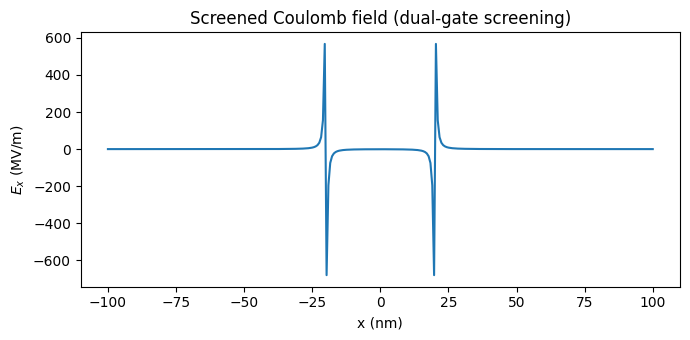

In [9]:
charges = np.array([
    [ 20e-9, 0, 0,  e_charge],   # (x, y, z, q)
    [-20e-9, 0, 0, -e_charge],
])

x_scan = np.linspace(-100e-9, 100e-9, 300)
Ex_vals = [
    E_disorder_point_charges(
        [xi, 0, d.z_defect], charges,
        epsilon_eff=d.epsilon_eff,
        screening_model=d.screening_model,
        lambda_screen=d.lambda_screen,
        d_gate=d.d_gate,
        n_images=d.n_images,
    )[0] for xi in x_scan
]

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(x_scan * 1e9, np.array(Ex_vals) / 1e6)
ax.set_xlabel("x (nm)"); ax.set_ylabel("$E_x$ (MV/m)")
ax.set_title("Screened Coulomb field (dual-gate screening)")
plt.tight_layout(); plt.show()

## 8. `ElectrometryExperiment` — scanning spatially resolved E-field sensing

`ElectrometryExperiment` combines a defect layer, a field source (from
`electrometry.efield`), and a sensing protocol to produce spatially resolved
lock-in signal maps — the simulated output of a NV/VB scanning electrometry
experiment.

SensingExperiment(N_def=300, T2*=50 ns, T2_echo=10 µs, contrast=0.029)
Echo:  peak ΔS = 0.1943 at τ = 3.61 µs
Ramsey peak ΔS = 0.0039 at τ = 50.2 ns


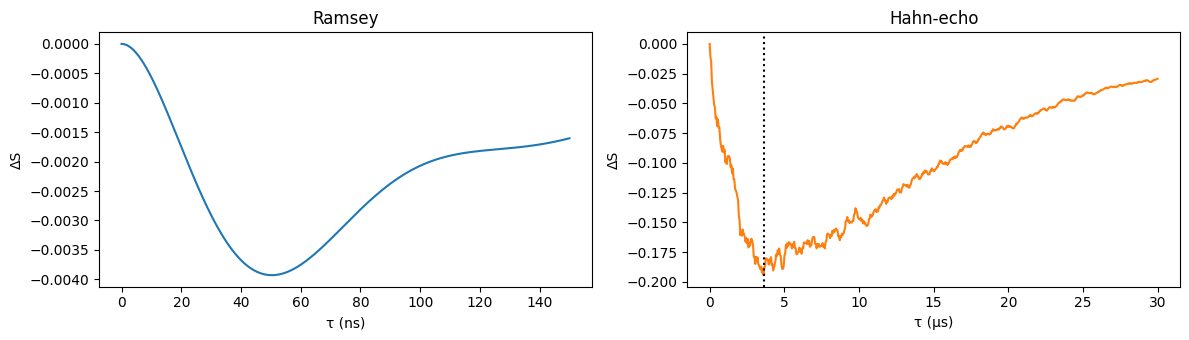

In [10]:
d = Defaults(T2echo=10e-6, B_mT=1.5)

ens = DefectEnsemble(N_def=300, defaults=d)
ens.generate_defects(seed=42)

# Random disorder charges
rng = np.random.default_rng(7)
n_dis = 20
xyzq = np.column_stack([
    rng.uniform(-d.R_patch, d.R_patch, (n_dis, 2)),
    np.zeros(n_dis),
    rng.choice([-1, 1], n_dis) * e_charge,
])
ens.compute_efields(disorder_xyzq=xyzq)

exp = ens.to_experiment(sensing="E")   # E-field sensing only
print(exp)

tau_s, Sw, Sn, dS, tau_opt, dS_peak = exp.echo_static()
tau_r, Sw_r, Sn_r, dS_r, tau_r_opt, dS_ramsey = exp.ramsey()
print(f"Echo:  peak ΔS = {dS_peak:.4f} at τ = {tau_opt*1e6:.2f} µs")
print(f"Ramsey peak ΔS = {dS_ramsey:.4f} at τ = {tau_r_opt*1e9:.1f} ns")

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(tau_r*1e9, dS_r); axes[0].set_xlabel("τ (ns)")
axes[0].set_ylabel("ΔS"); axes[0].set_title("Ramsey")

axes[1].plot(tau_s*1e6, dS, color="C1")
axes[1].axvline(tau_opt*1e6, color="k", ls=":")
axes[1].set_xlabel("τ (µs)"); axes[1].set_ylabel("ΔS"); axes[1].set_title("Hahn-echo")
plt.tight_layout(); plt.show()

## 9. Full ensemble E-field sensing

The `DefectEnsemble` class runs a full forward model:
1. Draws $N$ random defect positions in a disk of radius $R$.
2. Evaluates $\vec{E}^{(i)}$ at each position.
3. Builds per-defect Hamiltonians and computes $\delta f^{(i)}$.
4. Returns the ensemble-averaged lock-in signal $\overline{\Delta S}(\tau)$.


 n_charges  dS_peak  tau_opt_us
         5 0.046230    9.215359
        10 0.119853    6.510851
        20 0.219566    5.208681
        40 0.347074    4.457429


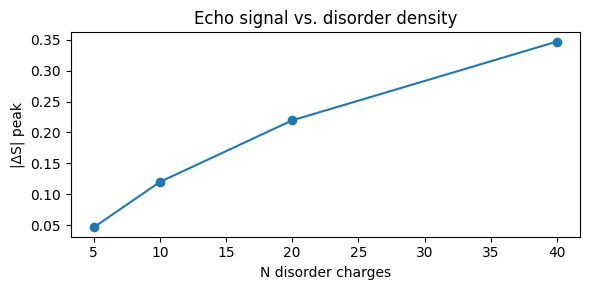

In [11]:
from SpinDefectSim.analysis.sweep import ParameterSweep
import pandas as pd

ps = ParameterSweep(N_def=150, seed=0)

def run(n_charges):
    en = ps.make_ensemble()
    rng2 = np.random.default_rng(1)
    n = int(n_charges)
    xyzq2 = np.column_stack([
        rng2.uniform(-d.R_patch, d.R_patch, (n, 2)),
        np.zeros(n),
        rng2.choice([-1, 1], n) * e_charge,
    ])
    en.compute_efields(disorder_xyzq=xyzq2)
    _, _, _, _, tau_opt2, dS_peak2 = en.to_experiment(sensing="E").echo_static()
    return dict(n_charges=n, dS_peak=dS_peak2, tau_opt_us=tau_opt2*1e6)

results = ps.sweep(run, n_charges=[5, 10, 20, 40])
df = pd.DataFrame(results)
print(df.to_string(index=False))

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(df.n_charges, df.dS_peak, "o-")
ax.set_xlabel("N disorder charges"); ax.set_ylabel("|ΔS| peak")
ax.set_title("Echo signal vs. disorder density")
plt.tight_layout(); plt.show()

## 10. Magnetic-field sources and `MagnetometryExperiment`

`B_from_magnetization_grid` computes the stray field over a 2-D magnetized region
by splitting contributions into edge currents (analytic Biot–Savart per segment) and
bulk currents ($\nabla\times\vec{M}$, see `theory.md §7`).

`MagnetometryExperiment` stitches together B-field evaluation, ensemble Hamiltonian,
sensing protocol, and SNR estimation into a scan-map simulator.

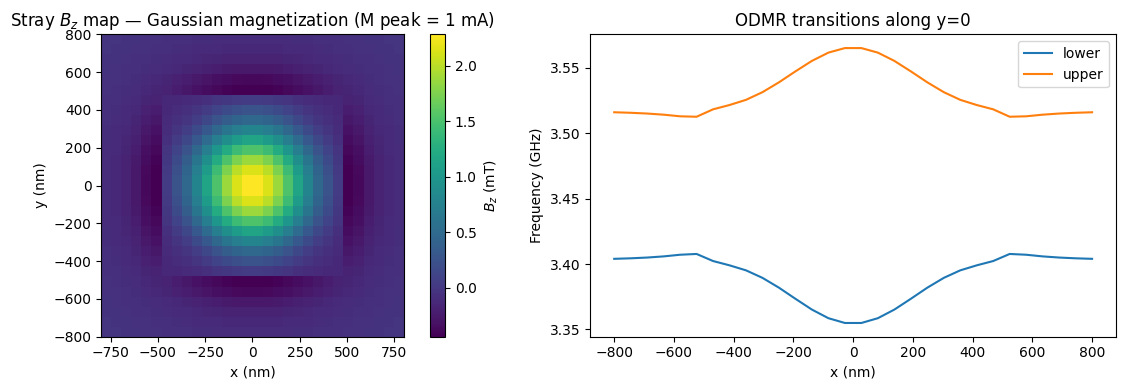

In [12]:
side = 1e-6
geom = SquareGeometry(side=side, n_boundary_pts=300)

def magnetization(x, y):
    sigma = side / 4
    # Peak magnetization 1 mA — realistic for a 2-D ferromagnet such as CrI₃.
    # M_z [A] = magnetic moment per unit area (A·m²/m² = A).
    return 1e-3 * np.exp(-(x**2 + y**2) / (2 * sigma**2))

mag_exp = MagnetometryExperiment(
    geom, magnetization=magnetization,
    defaults=d, z_defect=50e-9,
    bias_B_T=[0, 0, 1e-3],
)

x_arr = np.linspace(-800e-9, 800e-9, 30)
y_arr = np.linspace(-800e-9, 800e-9, 30)
Bz_map = mag_exp.B_z_map(x_arr, y_arr)

f_cut = np.array([mag_exp.transition_frequencies(xi, 0.0) for xi in x_arr])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
im = axes[0].imshow(Bz_map * 1e3, origin="lower", extent=[-800, 800, -800, 800])
plt.colorbar(im, ax=axes[0], label="$B_z$ (mT)")
axes[0].set_xlabel("x (nm)"); axes[0].set_ylabel("y (nm)")
axes[0].set_title("Stray $B_z$ map — Gaussian magnetization (M peak = 1 mA)")

axes[1].plot(x_arr*1e9, f_cut[:, 0]/1e9, label="lower")
axes[1].plot(x_arr*1e9, f_cut[:, 1]/1e9, label="upper")
axes[1].set_xlabel("x (nm)"); axes[1].set_ylabel("Frequency (GHz)")
axes[1].set_title("ODMR transitions along y=0"); axes[1].legend()
plt.tight_layout(); plt.show()

## 11. Combined E + B sensing

Both `ElectrometryExperiment` and `MagnetometryExperiment` inherit from
`SensingExperiment` and expose the same interface, so SNR calculations work
identically for both.  This cell shows how to combine a non-zero bias B field
with an E-field disorder source and extract the peak echo signal.

Combined E+B — peak |ΔS| = 1.1659 at τ = 0.04 µs


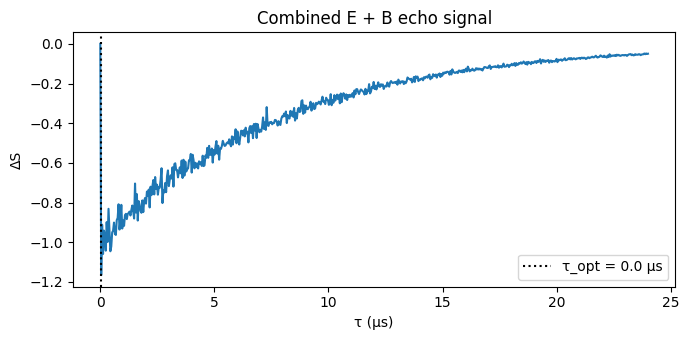

Averages for SNR=5: 43  →  integration time: 0.0 s


In [13]:
d_comb = Defaults(B_mT=2.0, T2echo=8e-6, T2star=1e-6)
ens2 = DefectEnsemble(N_def=200, defaults=d_comb)
ens2.generate_defects(seed=99)

# Add E-field disorder charges
rng3  = np.random.default_rng(13)
n_dis = 15
xyzq3 = np.column_stack([
    rng3.uniform(-d_comb.R_patch, d_comb.R_patch, (n_dis, 2)),
    np.zeros(n_dis),
    rng3.choice([-1, 1], n_dis) * e_charge,
])
ens2.compute_efields(disorder_xyzq=xyzq3)

# Add stray B-field at each defect from a current-carrying wire
# B_from_wire_segment(r_start, r_end, current_A, r_obs_xyz)
from SpinDefectSim.magnetometry.bfield import B_from_wire_segment
wire_start = np.array([-5e-6, 0, 0])
wire_end   = np.array([ 5e-6, 0, 0])
B_extra = np.array([
    B_from_wire_segment(
        wire_start, wire_end, 1e-3,
        np.array([xi, yi, d_comb.z_defect]),
    )
    for xi, yi in zip(
        ens2.defect_positions[:, 0],
        ens2.defect_positions[:, 1],
    )
])  # shape (N, 3)
ens2.set_bfields(B_extra)

exp2 = ens2.to_experiment(sensing="both")
tau_arr, _, _, dS2, tau_opt2, dS_peak2 = exp2.echo_static()
print(f"Combined E+B — peak |ΔS| = {dS_peak2:.4f} at τ = {tau_opt2*1e6:.2f} µs")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(tau_arr * 1e6, dS2)
ax.axvline(tau_opt2 * 1e6, color="k", ls=":", label=f"τ_opt = {tau_opt2*1e6:.1f} µs")
ax.set_xlabel("τ (µs)"); ax.set_ylabel("ΔS")
ax.set_title("Combined E + B echo signal"); ax.legend()
plt.tight_layout(); plt.show()

# SNR estimate
C_comb = d_comb.get_contrast()
n_needed = n_avg_for_threshold(
    dS_peak2, snr_target=5,
    contrast=C_comb, n_photons=d_comb.n_photons,
)
t_int = n_needed / HahnEchoSequence().repetition_rate(tau_opt2)
print(f"Averages for SNR=5: {n_needed:.0f}  →  integration time: {t_int:.1f} s")


## 12. Nuclear spins and hyperfine interaction

`NuclearSpin` encapsulates one nuclear spin with its hyperfine tensor $A$ (Hz),
gyromagnetic ratio $\gamma_n$, and quadrupole coupling $P$.

`full_hyperfine_hamiltonian_Hz` assembles the full tensor-product Hamiltonian
$\mathcal{H}_e \otimes \mathcal{H}_{n_1} \otimes \cdots$ (see `theory.md §10`):

$$
\frac{H}{h} = H_e \otimes \mathbf{1}_n
  + \mathbf{1}_e \otimes H_n
  + \sum_{ij} A^{ij}\, S_i \otimes I_j
$$

`odmr_transitions_Hz` filters the diagonalised spectrum for transitions
starting from states with dominant $|m_S=0\rangle_e$ character.


NuclearSpin(label='14N', I=1, A_diag=[-2.700, -2.700, -2.140] MHz, P=-4.950 MHz)
Hilbert-space dimension: 9  (3 electron × 3 nuclear)
NV⁻ hyperfine-split ODMR transitions (GHz):
  0.000000 GHz
  0.000005 GHz
  0.002807 GHz
  0.002813 GHz
  0.004285 GHz
  0.004947 GHz
  0.007093 GHz
  2.862915 GHz
  2.867195 GHz
  2.867863 GHz
  2.870008 GHz
  2.872143 GHz
  2.872148 GHz
  2.874955 GHz

VB⁻ + 3×¹⁴N Hilbert-space dimension: 81
Number of hyperfine-split transitions: 18


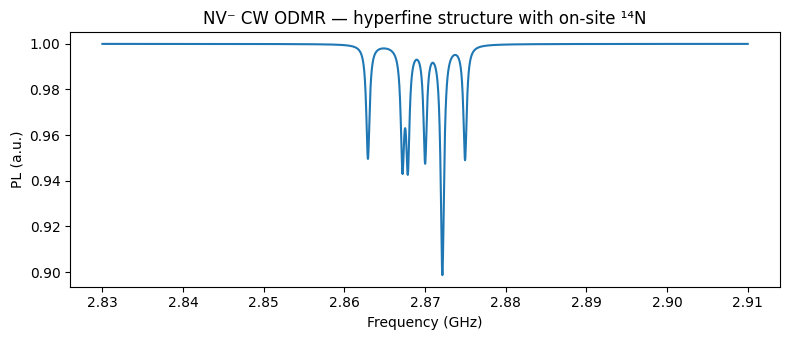

In [14]:
from SpinDefectSim.spin.nuclear import (
    NuclearSpin, axial_A_tensor, isotropic_A_tensor,
    GAMMA_14N, GAMMA_15N, GAMMA_13C,
)
from SpinDefectSim.spin.hamiltonian import (
    SpinParams, full_hyperfine_hamiltonian_Hz, odmr_transitions_Hz,
)

# ── NV⁻ on-site ¹⁴N (I = 1) ────────────────────────────────────────────────
N14_NV = NuclearSpin(
    spin=1,
    A_tensor_Hz=axial_A_tensor(A_zz_Hz=-2.14e6, A_perp_Hz=-2.70e6),
    gamma_Hz_T=GAMMA_14N,
    label="14N",
    quadrupole_Hz=-4.95e6,
)
print(N14_NV)

sp_nv = SpinParams(D0=2.87e9, E0=0.0, d_perp_Hz_per_Vpm=0.0, B_T=np.zeros(3))
H_nv = full_hyperfine_hamiltonian_Hz(sp_nv, E_vec_lab=[0, 0, 0], nuclear_spins=[N14_NV])
print(f"Hilbert-space dimension: {H_nv.shape[0]}  (3 electron × 3 nuclear)")

freqs_nv = odmr_transitions_Hz(H_nv, electron_dim=3, ms0_basis_index=1)
print("NV⁻ hyperfine-split ODMR transitions (GHz):")
for f in freqs_nv:
    print(f"  {f/1e9:.6f} GHz")

# ── VB⁻ three equivalent ¹⁴N neighbours ────────────────────────────────────
N14_VB = NuclearSpin(
    spin=1,
    A_tensor_Hz=axial_A_tensor(A_zz_Hz=0, A_perp_Hz=47.8e6),
    gamma_Hz_T=GAMMA_14N,
    label="14N_VB",
)
sp_vb = SpinParams(D0=3.46e9, E0=0.0, d_perp_Hz_per_Vpm=0.0, B_T=np.zeros(3))
H_vb = full_hyperfine_hamiltonian_Hz(
    sp_vb, E_vec_lab=[0, 0, 0], nuclear_spins=[N14_VB, N14_VB, N14_VB]
)
print(f"\nVB⁻ + 3×¹⁴N Hilbert-space dimension: {H_vb.shape[0]}")
freqs_vb = odmr_transitions_Hz(H_vb, electron_dim=3, ms0_basis_index=1)
print(f"Number of hyperfine-split transitions: {len(freqs_vb)}")

# ── Visualise NV⁻ hyperfine triplet ─────────────────────────────────────────
f_hf_axis = np.linspace(2.83e9, 2.91e9, 3000)
fwhm_hf = 0.5e6  # narrow linewidth to resolve hyperfine lines

spectrum = np.ones_like(f_hf_axis)
C_hf = 0.05  # reduced contrast per hyperfine line
for f0 in freqs_nv:
    spectrum -= C_hf * ((fwhm_hf/2)**2) / ((f_hf_axis - f0)**2 + (fwhm_hf/2)**2)

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(f_hf_axis / 1e9, spectrum)
ax.set_xlabel("Frequency (GHz)")
ax.set_ylabel("PL (a.u.)")
ax.set_title("NV⁻ CW ODMR — hyperfine structure with on-site ¹⁴N")
plt.tight_layout()
plt.show()


## 13. CW ODMR contrast — rate model

`RateModel` solves the optical / ISC steady-state rate equations for any spin-$S$
defect (see `theory.md §11`):

$$
C = \frac{\text{PL}_\text{off} - \text{PL}_\text{on}}{\text{PL}_\text{off}}
$$

Pre-built `RateParams` objects are provided for NV⁻, VB⁻, V_SiC, P1, and Cr/GaN.
`Defaults.get_contrast()` auto-computes $C$ from the rate model whenever
`contrast=None`.


Defect    Spin   Contrast
--------------------------------
NV⁻       S=1.0   50.0 %
VB⁻       S=1.0   2.9 %
V_SiC     S=1.0   38.1 %
P1        S=0.5   -0.0 %
Cr/GaN    S=1.5   0.0 %


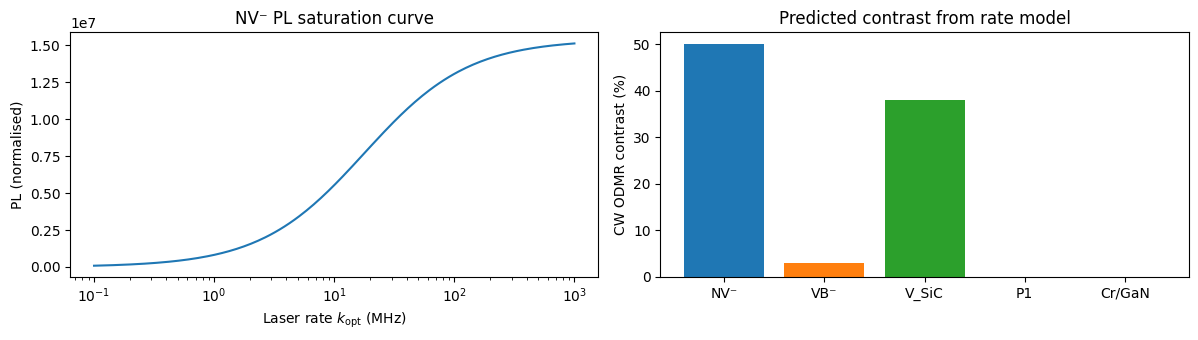


Custom defect contrast: 29.2 %
NV⁻ auto-contrast (Defaults): 50.0 %
VB⁻ auto-contrast (Defaults): 2.9 %


In [15]:
from SpinDefectSim.spin.rates import (
    RateModel, RateParams,
    NV_RATES, VB_RATES, VSIC_RATES, P1_RATES, CRGAN_RATES,
)

# ── Predicted CW contrast for each built-in defect ──────────────────────────
print(f"{'Defect':8s}  {'Spin':5s}  Contrast")
print("-" * 32)
for name, rp, ms0 in [
    ("NV⁻",    NV_RATES,   1),
    ("VB⁻",    VB_RATES,   1),
    ("V_SiC",  VSIC_RATES, 1),
    ("P1",     P1_RATES,   0),
    ("Cr/GaN", CRGAN_RATES, 1),
]:
    model = RateModel(rp, ms0_index=ms0)
    print(f"{name:8s}  S={rp.spin:.1f}   {model.contrast()*100:.1f} %")

# ── Steady-state PL vs. laser power ─────────────────────────────────────────
nv_model = RateModel(NV_RATES, ms0_index=1)

k_opt_range = np.logspace(5, 9, 200)  # 0.1 MHz … 1 GHz laser rate
pl_off = [RateModel(
    RateParams(spin=1, k_optical=k, k_rad=NV_RATES.k_rad,
               k_isc_excited=NV_RATES.k_isc_excited,
               k_from_shelving=NV_RATES.k_from_shelving),
    ms0_index=1).pl() for k in k_opt_range]

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))

# Left: PL saturation curve
axes[0].semilogx(k_opt_range / 1e6, pl_off)
axes[0].set_xlabel("Laser rate $k_\\mathrm{opt}$ (MHz)")
axes[0].set_ylabel("PL (normalised)")
axes[0].set_title("NV⁻ PL saturation curve")

# Right: contrast bar chart for all defects
defects  = ["NV⁻", "VB⁻", "V_SiC", "P1", "Cr/GaN"]
contrasts = []
for rp, ms0 in [(NV_RATES, 1), (VB_RATES, 1), (VSIC_RATES, 1),
                (P1_RATES, 0), (CRGAN_RATES, 1)]:
    contrasts.append(RateModel(rp, ms0_index=ms0).contrast() * 100)

axes[1].bar(defects, contrasts, color=["C0", "C1", "C2", "C3", "C4"])
axes[1].set_ylabel("CW ODMR contrast (%)")
axes[1].set_title("Predicted contrast from rate model")

plt.tight_layout()
plt.show()

# ── Custom rate model ────────────────────────────────────────────────────────
custom_rp = RateParams(
    spin=1,
    k_optical=20e6,
    k_rad=100e6,
    k_isc_excited=[50e6, 5e6, 50e6],   # ms = +1, 0, −1
    k_from_shelving=[0.0, 10e6, 0.0],  # spin-polarising return to ms = 0
)
custom_model = RateModel(custom_rp, ms0_index=1)
print(f"\nCustom defect contrast: {custom_model.contrast()*100:.1f} %")

# ── Auto-computed contrast via Defaults ─────────────────────────────────────
d_nv = Defaults.for_defect("nv_minus")         # contrast=None → auto-compute
print(f"NV⁻ auto-contrast (Defaults): {d_nv.get_contrast(d_nv.k_optical)*100:.1f} %")

d_vb = Defaults()                               # VB⁻ default
print(f"VB⁻ auto-contrast (Defaults): {d_vb.get_contrast(d_vb.k_optical)*100:.1f} %")
